In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import torch

In [2]:
data = pd.read_excel("input/GS.xlsx")

In [3]:
data.describe()

,C1 (Mass Fraction),C2 (Mass Fraction),C3 (Mass Fraction),IC4 (Mass Fraction),NC4 (Mass Fraction),N2 (Mass Fraction),CO2 (Mass Fraction),H2S (Mass Fraction),NG Mass Flow (Kg/hr),Reg Molar RR,HEX_T-HOT (C),P-OUT (bar),Sweetened Gas (CO2),Sweetened Gas (H2S),Water Make-up (Mole/hr),MDEA Make-up (KMole/hr),Exergy (KW),HHV (Kj/cum)
count,511256.000000,511256.000000,511256.000000,511256.000000,511256.000000,511256.000000,511256.000000,511256.000000,511256.000000,511256.000000,511256.000000,511256.000000,511256.000000,5.112560e+05,511256.000000,511256.000000,511256.000000,511256.000000
mean,77.219948,5.521694,5.474263,2.883633,2.596500,3.784581,1.966773,0.552608,490462.837763,2.822226,60.534803,9.639564,0.008216,6.813112e-07,434007.205237,0.009151,74146.317994,42541.339365
std,3.230443,1.689582,1.543937,1.480793,1.772752,1.320244,1.150108,0.360680,36750.492800,0.382141,12.236502,4.523169,0.004853,2.185965e-07,95250.410143,0.001110,5668.953436,945.019554
min,64.666010,2.428475,2.440739,0.800476,0.251011,1.600925,0.166228,0.041771,371768.168000,2.300000,45.000000,4.000000,0.000691,1.999793e-07,310946.421000,0.006611,60692.020100,39250.486200
25%,75.115312,3.976884,4.521433,1.285921,0.675283,2.580479,0.889508,0.303332,465258.168000,2.300000,45.000000,4.000000,0.003620,5.223182e-07,326260.612750,0.008163,70125.281725,41931.633800
50%,77.181610,5.634227,5.219382,2.864820,2.789015,3.705235,1.834664,0.682587,488638.279000,2.700000,60.000000,10.000000,0.007516,6.616520e-07,389839.030500,0.009267,73743.904700,42559.032950
75%,79.289207,6.875620,6.682164,4.244600,4.298018,4.718171,2.926325,0.893440,512782.425000,3.300000,75.000000,14.000000,0.012313,8.164642e-07,494297.100750,0.010137,77804.438400,43163.743175
max,90.431421,10.070793,10.070793,6.138764,6.087227,7.377651,4.874693,1.270933,620082.425000,3.300000,75.000000,16.000000,0.019419,1.524292e-06,575764.841000,0.011831,89588.989900,46387.057000


In [3]:
# Separate features (first 11 columns) and target
X = data.iloc[:, :12].values  # First 11 columns as features
y = data['Water Make-up (Mole/hr)'].values.reshape(-1, 1)  # Target variable, reshaped to 2D

In [4]:
# Split data into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42)

In [5]:
# Confirming the split ratios
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

Training set: (286302, 12), Validation set: (122702, 12), Test set: (102252, 12)


In [6]:
# Scale features
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

In [7]:
# Scale target using MinMaxScaler (or StandardScaler for more normalized distribution)
scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val = scaler_y.transform(y_val.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))

In [11]:
# Initialize the TabNet model with a balanced configuration
model3 = TabNetRegressor(
    n_d=32,  # Feature embeddings
    n_a=32,  # Attention embeddings
    n_steps=5,  # Number of decision steps
    gamma=1.5,  # Feature reusage penalty
    n_independent=2,  # Independent FC layers
    n_shared=2,  # Shared FC layers
    lambda_sparse=1e-3,  # Sparsity regularization
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(lr=1e-2, weight_decay=1e-5),
    mask_type='entmax',  # Sparsemax for feature selection
    scheduler_fn=torch.optim.lr_scheduler.OneCycleLR,
    scheduler_params={"max_lr": 0.03, 
                      "steps_per_epoch": X_train.shape[0] // 32,
                      "epochs": 300,
                      "pct_start": 0.3, "anneal_strategy": "cos", "div_factor": 10}
)

In [10]:
# Train the model with validation monitoring
model3.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['rmse'],
    max_epochs=500,  # More epochs for thorough training
    patience=50,  # Higher patience for better convergence
    batch_size=16,  # Larger batch size
    virtual_batch_size=32,
    num_workers=0,
    drop_last=False
)

c:\Users\mostafa\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


epoch 0  | loss: 0.60087 | val_rmse: 0.11561 |  0:50:11s
epoch 1  | loss: 0.01844 | val_rmse: 0.06467 |  1:46:13s
epoch 2  | loss: 0.00916 | val_rmse: 0.05774 |  2:45:04s
epoch 3  | loss: 0.00504 | val_rmse: 0.06043 |  3:45:54s
epoch 4  | loss: 0.00378 | val_rmse: 0.04085 |  4:54:14s
epoch 5  | loss: 0.00282 | val_rmse: 0.05544 |  6:10:47s
epoch 6  | loss: 0.00229 | val_rmse: 0.05782 |  7:29:53s
epoch 7  | loss: 0.00177 | val_rmse: 0.04363 |  9:02:16s
epoch 8  | loss: 0.00128 | val_rmse: 0.02255 |  11:22:30s
epoch 9  | loss: 0.00089 | val_rmse: 0.11737 |  14:25:22s
epoch 10 | loss: 0.00048 | val_rmse: 0.05798 |  17:40:33s
epoch 11 | loss: 0.00038 | val_rmse: 0.07032 |  21:21:46s
epoch 12 | loss: 0.00035 | val_rmse: 0.0927  |  1 day, 1:01:39s
epoch 13 | loss: 0.00031 | val_rmse: 0.05775 |  1 day, 4:41:31s
epoch 14 | loss: 0.00028 | val_rmse: 0.04334 |  1 day, 8:07:59s
epoch 15 | loss: 0.00028 | val_rmse: 0.06964 |  1 day, 11:26:09s
epoch 16 | loss: 0.00025 | val_rmse: 0.10404 |  1 day, 

KeyboardInterrupt: 

In [12]:
# Train the model with validation monitoring
model3.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['rmse'],
    max_epochs=6,  # More epochs for thorough training
    patience=20,  # Higher patience for better convergence
    batch_size=32,  # Larger batch size
    virtual_batch_size=16,
    num_workers=0,
    drop_last=True
)

epoch 0  | loss: 0.02942 | val_rmse: 0.04512 |  0:08:42s
epoch 1  | loss: 0.00241 | val_rmse: 0.04737 |  0:17:40s
epoch 2  | loss: 0.00108 | val_rmse: 0.06809 |  0:26:37s
epoch 3  | loss: 0.00041 | val_rmse: 0.11498 |  0:34:54s
epoch 4  | loss: 0.00031 | val_rmse: 0.1011  |  0:43:05s
epoch 5  | loss: 0.0003  | val_rmse: 0.0711  |  0:51:15s
Stop training because you reached max_epochs = 6 with best_epoch = 0 and best_val_rmse = 0.04512


c:\Users\mostafa\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [13]:
# Predict and rescale on the test set
y_pred_scaled = model3.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # Inverse transform to original scale
y_test_original = scaler_y.inverse_transform(y_test)  # Original scale for comparison

In [14]:
# Evaluate performance with MSE and R²
import numpy as np

mse = mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)
rmse = np.sqrt(mse)
print(f'Mean Squared Error on Test Set: {mse}')
print(f'R² Score on Test Set: {r2}')
print(f'RMSE for MH2O(MOL/HR): {rmse}')

Mean Squared Error on Test Set: 142707475.93921542
R² Score on Test Set: 0.9843076594559148
RMSE for MH2O(MOL/HR): 11946.023436240841


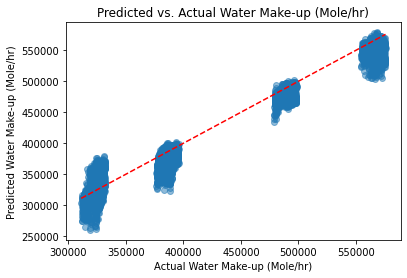

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.xlabel("Actual Water Make-up (Mole/hr)")
plt.ylabel("Predicted Water Make-up (Mole/hr)")
plt.title("Predicted vs. Actual Water Make-up (Mole/hr)")
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--')
plt.show()

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [17]:
# Set plot style for a professional look
sns.set(style="whitegrid", palette="muted")

C:\Users\mostafa\AppData\Local\Temp\ipykernel_4516\1328164743.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(sc)


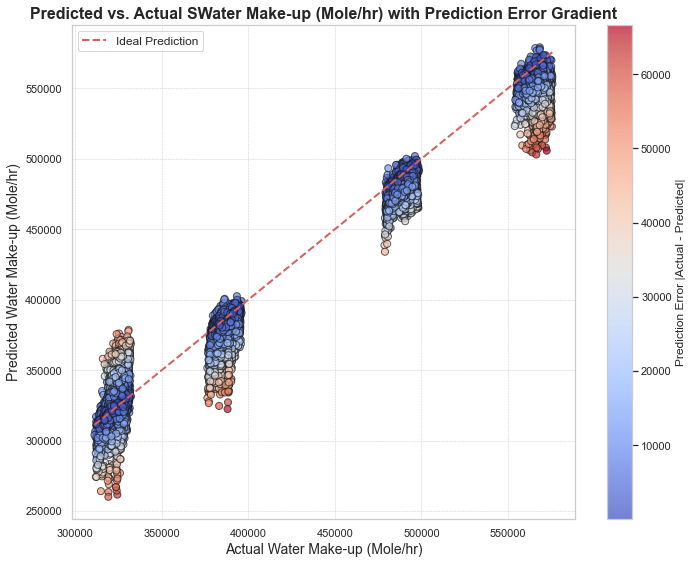

In [18]:
# Set plot style for a professional look
sns.set(style="whitegrid", palette="muted")

# Set figure size and create a scatter plot with color gradient
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    y_test_original, y_pred, 
    c=np.abs(y_pred - y_test_original), 
    cmap="coolwarm", s=50, alpha=0.7, edgecolor="k"
)

# Add color bar to indicate prediction error (absolute difference)
cbar = plt.colorbar(sc)
cbar.set_label("Prediction Error |Actual - Predicted|", fontsize=12)

# Plot a 1:1 line for reference
plt.plot(
    [y_test_original.min(), y_test_original.max()], 
    [y_test_original.min(), y_test_original.max()], 
    'r--', lw=2, label="Ideal Prediction"
)

# Set axis labels and title with enhanced font size
plt.xlabel("Actual Water Make-up (Mole/hr)", fontsize=14)
plt.ylabel("Predicted Water Make-up (Mole/hr)", fontsize=14)
plt.title("Predicted vs. Actual SWater Make-up (Mole/hr) with Prediction Error Gradient", fontsize=16, fontweight='bold')

# Customize legend and plot aesthetics
plt.legend(loc="upper left", fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Show plot
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import ScalarFormatter, FuncFormatter

# Set Arial font for professional look
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

errors = np.abs(y_pred - y_test_original)
relative_errors = errors / (np.abs(y_test_original) + 1e-10) * 100

r2 = r2_score(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae = mean_absolute_error(y_test_original, y_pred)
mape = np.mean(relative_errors)

sample_size = min(5000, len(y_test_original))
if len(y_test_original) > sample_size:
    indices = np.random.choice(len(y_test_original), sample_size, replace=False)
    y_test_sample = y_test_original[indices]
    y_pred_sample = y_pred[indices]
    errors_sample = errors[indices]
else:
    y_test_sample = y_test_original
    y_pred_sample = y_pred
    errors_sample = errors

fig, ax = plt.subplots(figsize=(11, 9), dpi=1000, facecolor='white')
ax.set_facecolor('#FAFAFA')

sc = ax.scatter(
    y_test_sample, y_pred_sample,
    c=errors_sample,
    cmap='RdYlBu_r',
    s=50,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
    zorder=2
)

ax.text(0.02, 0.98, '(c)', transform=ax.transAxes, fontsize=35, 
        fontweight='bold', verticalalignment='top', color='black')

# ========== Color bar ==========
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

cbar.set_label('Absolute Error |Actual - Predicted|', 
               fontsize=29, fontweight='bold', labelpad=10)

cbar.ax.text(0.5, 1.02, '×10³', transform=cbar.ax.transAxes, 
             fontsize=27, fontweight='bold', ha='center', va='bottom')

def format_colorbar(value, tick_number):
    return f'{value / 1000:.0f}'

cbar.ax.yaxis.set_major_formatter(FuncFormatter(format_colorbar))
cbar.ax.tick_params(labelsize=25)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

# ========== 1:1 Ideal Line ==========
min_val = float(y_test_sample.min())
max_val = float(y_test_sample.max())

ax.plot([min_val, max_val], [min_val, max_val], 
        'k-', linewidth=2.5, label='Ideal Prediction (1:1)', 
        color='#333333', zorder=1)

# ========== Regression Line ==========
regressor = LinearRegression()
regressor.fit(y_test_sample.reshape(-1, 1), y_pred_sample)
slope_value = float(regressor.coef_[0])
intercept_value = float(regressor.intercept_)

regression_line = regressor.predict(np.array([min_val, max_val]).reshape(-1, 1))

ax.plot([min_val, max_val], regression_line, 
        'r--', linewidth=3, label=f'Regression Line (slope={slope_value:.3f})', 
        alpha=0.9, zorder=1, color='#DC143C')

# ========== Labels and Title ==========
ax.set_xlabel('Actual Water Make-up', fontsize=35, fontweight='bold', labelpad=12)
ax.set_ylabel('Predicted Water Make-up', fontsize=35, fontweight='bold', labelpad=12)

# ========== Axis Limits and Ticks ==========
ax.set_xlim(min_val - 0.05 * abs(min_val), max_val + 0.05 * abs(max_val))
ax.set_ylim(min_val - 0.05 * abs(min_val), max_val + 0.05 * abs(max_val))

divisor = 10000  # 10⁴

def scientific_format(x, pos):
    return f'{x/divisor:.1f}'

ax.xaxis.set_major_formatter(FuncFormatter(scientific_format))
ax.yaxis.set_major_formatter(FuncFormatter(scientific_format))

ax.text(0.99, -0.12, '×10⁴', transform=ax.transAxes, 
        fontsize=27, fontweight='bold', ha='center', va='bottom')

ax.text(0.07, 1.03, '×10⁴', transform=ax.transAxes, 
        fontsize=27, fontweight='bold', ha='center', va='center')

# ========== Tick parameters ==========
ax.tick_params(axis='both', which='major', labelsize=30, width=1.5, length=8, 
               colors='#333333')

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(30)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(30)

ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.6, color='#cccccc')
ax.set_axisbelow(True)

# ========== Spines ==========
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#333333')
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# ========== Legend ==========
legend = ax.legend(loc='upper center', frameon=True, fancybox=False,
                   fontsize=19, edgecolor='#333333', facecolor='white',
                   framealpha=1, borderpad=0.8, bbox_to_anchor=(0.5, 0.99))
legend.get_frame().set_linewidth(1.2)

# ========== Highlight worst prediction ==========
worst_idx = np.argmax(errors_sample)
ax.scatter([y_test_sample[worst_idx]], [y_pred_sample[worst_idx]], 
           s=200, c='red', marker='*', edgecolor='black', linewidth=1.5, 
           label='Worst Prediction', zorder=4)

info_text = (f'R² = {r2:.4f}\n'
             f'RMSE = {rmse:.2f}')

props = dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.95,
             edgecolor='#999999', linewidth=1.5)
ax.text(0.96, 0.04, info_text, transform=ax.transAxes, fontsize=20,
        horizontalalignment='right', verticalalignment='bottom', 
        bbox=props, family='Arial', fontweight='bold')

plt.tight_layout()

# Show
plt.show()

# Save
# plt.savefig('Model_Performance_Water_Makeup.png', dpi=300, bbox_inches='tight', facecolor='white')

C:\Users\mostafa\AppData\Local\Temp\ipykernel_4516\3762355646.py:56: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
C:\Users\mostafa\AppData\Local\Temp\ipykernel_4516\3762355646.py:79: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min_val, max_val], [min_val, max_val],
C:\Users\mostafa\AppData\Local\Temp\ipykernel_4516\3762355646.py:91: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot([min_val, max_val], regression_line,


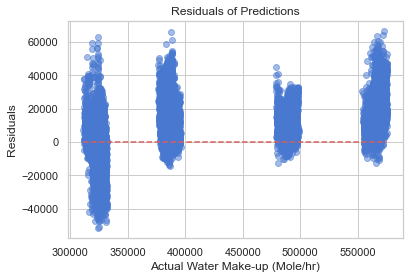

In [22]:
residuals = y_test_original - y_pred
plt.scatter(y_test_original, residuals, alpha=0.5)
plt.hlines(0, y_test_original.min(), y_test_original.max(), colors='r', linestyles='dashed')
plt.xlabel("Actual Water Make-up (Mole/hr)")
plt.ylabel("Residuals")
plt.title("Residuals of Predictions")
plt.show()

In [23]:
feature_importances = 3.feature_importances_
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance for Water Make-up (Mole/hr) Prediction")
plt.show()

SyntaxError: invalid decimal literal (813559108.py, line 1)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
# Example feature names (replace with actual feature names if available)
feature_names = ["C1 (Mass Fraction)", "C2 (Mass Fraction)","C3 (Mass Fraction)","IC4 (Mass Fraction)","NC4 (Mass Fraction)","N2 (Mass Fraction)","CO2 (Mass Fraction)","H2S (Mass Fraction)","NG Mass Flow (Kg/hr)","Reg Molar RR","HEX_T-HOT (C)","P-OUT (bar)"]

In [26]:
# Feature importances from the model
feature_importances = model3.feature_importances_

In [27]:
# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

In [28]:
# Sort by importance for a more informative visualization
importance_df = importance_df.sort_values(by="Importance", ascending=True)

In [29]:
# Set up a larger, more readable figure size
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid")


<Figure size 720x576 with 0 Axes>

<AxesSubplot:xlabel='Importance', ylabel='Feature'>

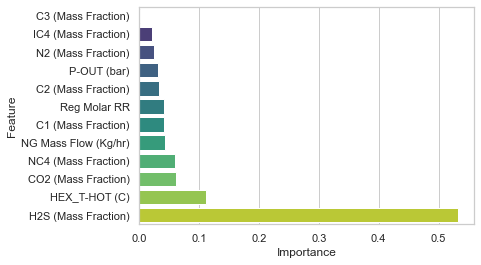

In [30]:
# Horizontal bar plot
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")

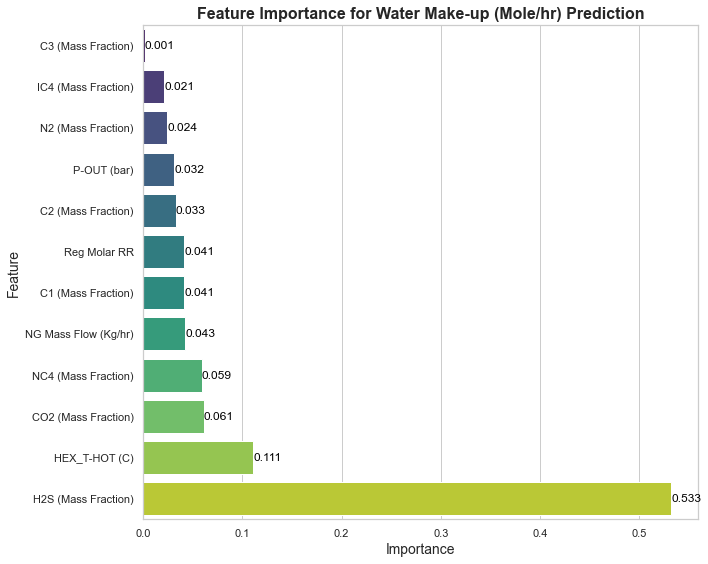

In [31]:


# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance for a more informative visualization
importance_df = importance_df.sort_values(by="Importance", ascending=True)

# Set up a larger, more readable figure size
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid")

# Horizontal bar plot
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")

# Add title and labels
plt.title("Feature Importance for Water Make-up (Mole/hr) Prediction", fontsize=16, fontweight='bold')
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)

# Add data labels to each bar for clarity
for index, value in enumerate(importance_df['Importance']):
    plt.text(value, index, f'{value:.3f}', color='black', ha="left", va="center")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# ============================================
# ============================================
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df['Importance_Pct'] = importance_df['Importance'] * 100

# ============================================
# ============================================
plt.rcParams.update({
    'font.family': 'arial',
    'font.serif': ['Times New Roman'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 26,
    'ytick.labelsize': 19,
    'legend.fontsize': 9,
    'figure.dpi': 600,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 1,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.direction': 'in',
    'ytick.direction': 'in'
})

# ============================================# ============================================
n_features = len(importance_df)

if n_features <= 5:
    fig_height = 3.5
elif n_features <= 8:
    fig_height = 4.5
elif n_features <= 12:
    fig_height = 5.5
else:
    fig_height = 6.5

fig, ax = plt.subplots(figsize=(12, fig_height), dpi=1000)

# ============================================
# ============================================
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(importance_df)))

bars = ax.barh(importance_df['Feature'], importance_df['Importance_Pct'],
               color=colors, edgecolor='black', linewidth=0.7,
               alpha=0.85, height=0.65, zorder=2)

# ============================================
# ============================================
for i, (val, bar) in enumerate(zip(importance_df['Importance_Pct'], bars)):
    ax.text(val + 1.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=16, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      edgecolor='#cccccc', alpha=0.8))

# ============================================
# ============================================
threshold = 10
if importance_df['Importance_Pct'].max() > threshold:
    ax.axvline(x=threshold, color='red', linestyle='--', linewidth=1,
               alpha=0.8, zorder=1)
    ax.text(threshold + 0.5, +11, f'Threshold ({threshold}%)',
            fontsize=15, color='red', alpha=0.8, ha='left',
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.6))

# ============================================
# ============================================
ax.set_xlabel('(b) Feature Importance for Water Make-up Prediction (%)', 
              fontsize=28, fontweight='semibold', labelpad=8)
ax.set_ylabel('Input Features', fontsize=28, fontweight='semibold', labelpad=8)

ax.grid(axis='x', linestyle='--', alpha=0.6, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='', alpha=0)

x_max = importance_df['Importance_Pct'].max()
ax.set_xlim(0, x_max + 8)

# ============================================
# ============================================
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                           norm=plt.Normalize(vmin=0, vmax=importance_df['Importance_Pct'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.75, aspect=25)
cbar.set_label('Importance Intensity →', fontsize=28, rotation=270, labelpad=30)
cbar.set_ticks([])

# ============================================
# ============================================
info_text = f"Total: {len(importance_df)} features\nTop: {importance_df.iloc[0]['Feature'][:14]} ({importance_df.iloc[0]['Importance_Pct']:.1f}%)"

props = dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='#999999', alpha=0.8)
ax.text(0.98, 0.97, info_text, transform=ax.transAxes, fontsize=16,
        verticalalignment='top', horizontalalignment='right',
        bbox=props, fontfamily='monospace')

# ============================================
# ============================================
ax.set_facecolor('#fafbfc')
fig.patch.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_color('#333333')
    spine.set_linewidth(1)

# ============================================
# ============================================
plt.subplots_adjust(left=0.15, right=0.92, top=0.9, bottom=0.1)
plt.tight_layout()

plt.savefig('feature_importance_water_makeup.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.savefig('feature_importance_water_makeup.pdf', bbox_inches='tight')
plt.savefig('feature_importance_water_makeup.svg', bbox_inches='tight')



plt.show()

C:\Users\mostafa\AppData\Local\Temp\ipykernel_4516\1103030167.py:113: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.75, aspect=25)


✅ گراف Water Make-up ذخیره شد. ابعاد: 12×5.5 اینچ
📊 مهم‌ترین ویژگی: H2S (Mass Fraction) با 53.3%
🎨 رنگ‌بندی: viridis
